In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load all binned monthly files by stacking them strictly along the time dimension
ds = xr.open_mfdataset(
    'data_products_monthly/*.nc', 
    combine='nested', 
    concat_dim='ping_time'
)

# Quick check to make sure it loaded correctly
print(ds)

C:\Users\tofar\AppData\Local\Temp\ipykernel_30536\1997564381.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'channel' ('channel',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(
C:\Users\tofar\AppData\Local\Temp\ipykernel_30536\1997564381.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(


ValueError: 'echo_range' not present in all datasets and coords='different'. Either add 'echo_range' to datasets where it is missing or specify coords='minimal'.

In [4]:
import glob
import xarray as xr

# Get a list of all your monthly nc files
file_paths = glob.glob('data_products_monthly/OTEC6013/*.nc')

print("--- Inspecting Monthly NetCDF Files ---\n")

for path in file_paths:
    print(f"Inspecting: {path}")
    
    # Open the single dataset
    with xr.open_dataset(path) as ds_temp:
        
        # 1. Print Coordinates
        print(f"  Coordinates: {list(ds_temp.coords.keys())}")
        
        # 2. Print Data Variables (like Sv)
        print(f"  Data Variables: {list(ds_temp.data_vars.keys())}")
        
        # 3. Check specifically for the missing 'echo_range'
        if 'echo_range' in ds_temp.variables:
            # If it's there, check its shape
            print(f"  'echo_range' status: PRESENT (Shape: {ds_temp['echo_range'].shape})")
        else:
            print(f"  'echo_range' status: MISSING  <--- HERE IS THE PROBLEM")
            
        print("-" * 60)

--- Inspecting Monthly NetCDF Files ---

Inspecting: data_products_monthly/OTEC6013\202301_2m.nc
  Coordinates: ['ping_time', 'channel', 'depth']
  Data Variables: ['Sv', 'frequency_nominal']
  'echo_range' status: MISSING  <--- HERE IS THE PROBLEM
------------------------------------------------------------
Inspecting: data_products_monthly/OTEC6013\202302_2m.nc
  Coordinates: ['ping_time', 'channel', 'depth']
  Data Variables: ['Sv', 'frequency_nominal']
  'echo_range' status: MISSING  <--- HERE IS THE PROBLEM
------------------------------------------------------------
Inspecting: data_products_monthly/OTEC6013\202303_2m.nc
  Coordinates: ['ping_time', 'channel', 'depth']
  Data Variables: ['Sv', 'frequency_nominal']
  'echo_range' status: MISSING  <--- HERE IS THE PROBLEM
------------------------------------------------------------
Inspecting: data_products_monthly/OTEC6013\202304_2m.nc
  Coordinates: ['ping_time', 'channel', 'depth']
  Data Variables: ['Sv', 'frequency_nominal']
 

In [1]:
import glob
import xarray as xr

# Get the list of all monthly files (sorted chronologically)
file_paths = sorted(glob.glob('data_products_monthly/*.nc'))

print("--- Verifying Frequency Channels Across Months ---\n")

for path in file_paths:
    print(f"File: {path.split('/')[-1].split('\\')[-1]}")  # Cleans up the path name for printing
    
    with xr.open_dataset(path) as ds_temp:
        # 1. Check how many channels exist
        num_channels = ds_temp.sizes.get('channel', 'MISSING')
        print(f"  Total Channels: {num_channels}")
        
        # 2. Print the exact frequency values to see which one dropped
        if 'frequency_nominal' in ds_temp.variables:
            freqs = ds_temp['frequency_nominal'].values
            print(f"  Frequencies (Hz): {freqs}")
        else:
            print("  Frequencies (Hz): Variable 'frequency_nominal' is missing")
            
    print("-" * 50)

--- Verifying Frequency Channels Across Months ---

File: 1711_5m_cleaned.nc
  Total Channels: 4
  Frequencies (Hz): [[125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 ...
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]]
--------------------------------------------------
File: 201711_2m.nc
  Total Channels: 4
  Frequencies (Hz): [[125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 ...
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]]
--------------------------------------------------
File: 201712_2m.nc
  Total Channels: 4
  Frequencies (Hz): [[125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 ...
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]
 [125000. 200000.  38000.  67000.]]
---------------

1. Loading datasets...
2. Linearizing Sv to sv...
3. Calculating Center of Mass...
4. Generating Plots...


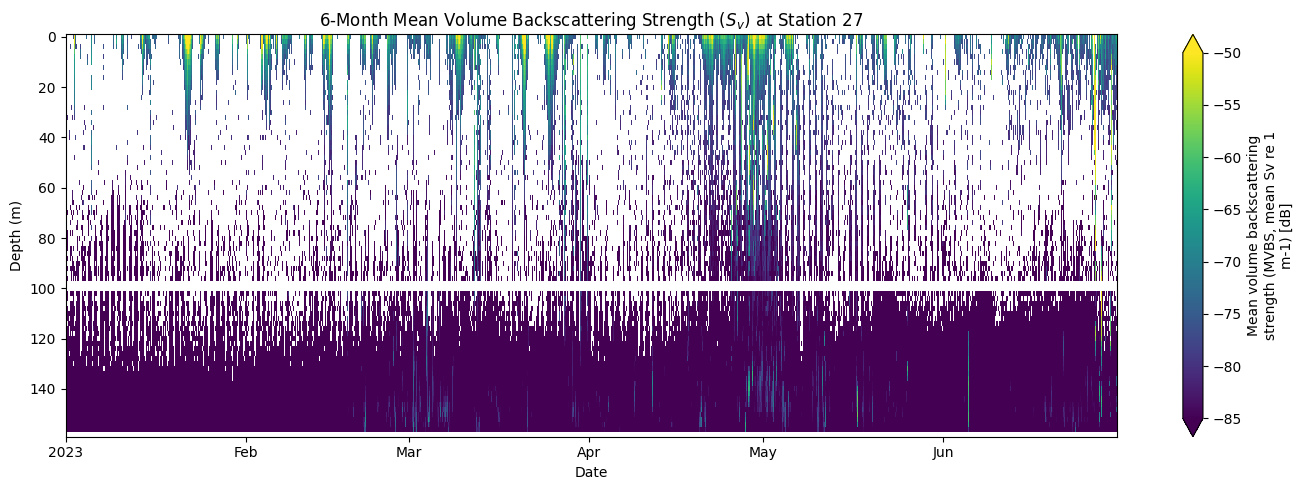

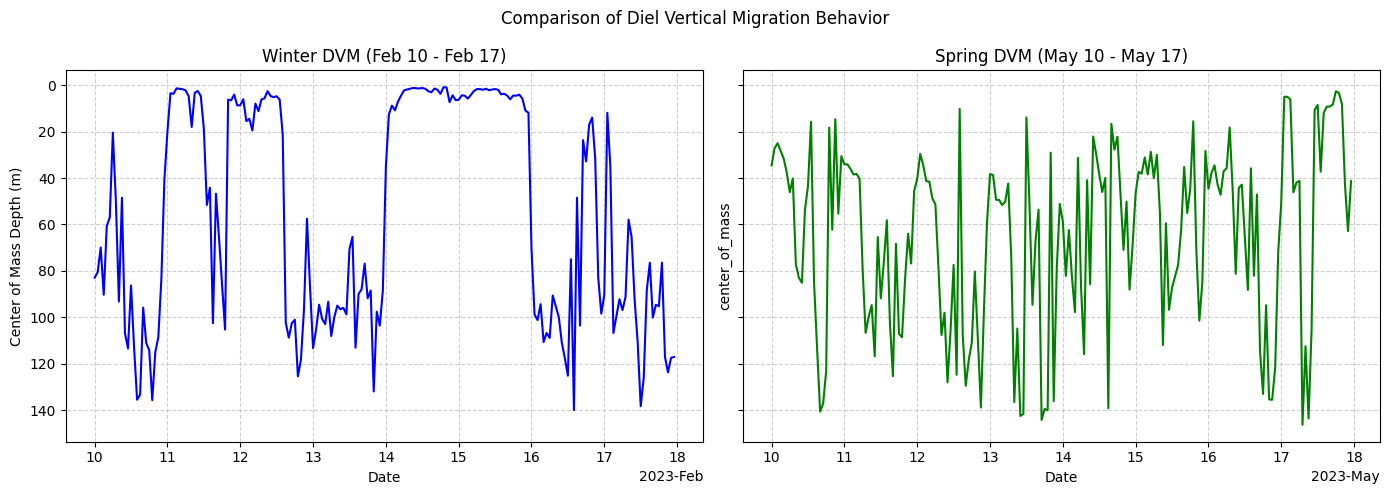

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress xarray warnings for a cleaner console output
warnings.filterwarnings('ignore', category=FutureWarning)

print("1. Loading datasets...")
# We add join='override' to force the depth bins to align perfectly
ds = xr.open_mfdataset(
    'data_products_monthly/OTEC6013/*.nc', 
    combine='nested', 
    concat_dim='ping_time',
    coords='minimal',
    compat='override',
    join='override',             
    drop_variables='echo_range'
)

# Select the first frequency channel and squeeze out any leftover dimensions
ds_chan = ds.isel(channel=0).squeeze()

print("2. Linearizing Sv to sv...")
# Convert logarithmic Sv (dB) to linear sv
ds_chan['sv_linear'] = 10 ** (ds_chan['Sv'] / 10)

print("3. Calculating Center of Mass...")
# Calculate the weighted mean depth
ds_chan['center_of_mass'] = (ds_chan['sv_linear'] * ds_chan.depth).sum(dim='depth') / ds_chan['sv_linear'].sum(dim='depth')

print("4. Generating Plots...")
# --- PLOT A: 6-Month Echogram ---
plt.figure(figsize=(14, 5))
# We use .plot.pcolormesh() to strictly enforce a 2D heatmap
ds_chan['Sv'].plot.pcolormesh(
    x='ping_time', 
    y='depth', 
    yincrease=False,  
    cmap='viridis', 
    vmin=-85,         
    vmax=-50
)
plt.title("6-Month Mean Volume Backscattering Strength ($S_v$) at Station 27")
plt.ylabel("Depth (m)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

# --- PLOT B: Winter vs Spring DVM Comparison ---
# Slice one week in February (Winter) and one week in May (Spring bloom)
winter_dvm = ds_chan['center_of_mass'].sel(ping_time=slice('2023-02-10', '2023-02-17'))
spring_dvm = ds_chan['center_of_mass'].sel(ping_time=slice('2023-05-10', '2023-05-17'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Winter Plot
winter_dvm.plot(ax=axes[0], color='blue')
axes[0].invert_yaxis() 
axes[0].set_title("Winter DVM (Feb 10 - Feb 17)")
axes[0].set_ylabel("Center of Mass Depth (m)")
axes[0].set_xlabel("Date")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Spring Plot
spring_dvm.plot(ax=axes[1], color='green')
axes[1].set_title("Spring DVM (May 10 - May 17)")
axes[1].set_xlabel("Date")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Comparison of Diel Vertical Migration Behavior")
plt.tight_layout()
plt.show()

Calculating advanced metrics...
Generating 6-Month Macro Plot...


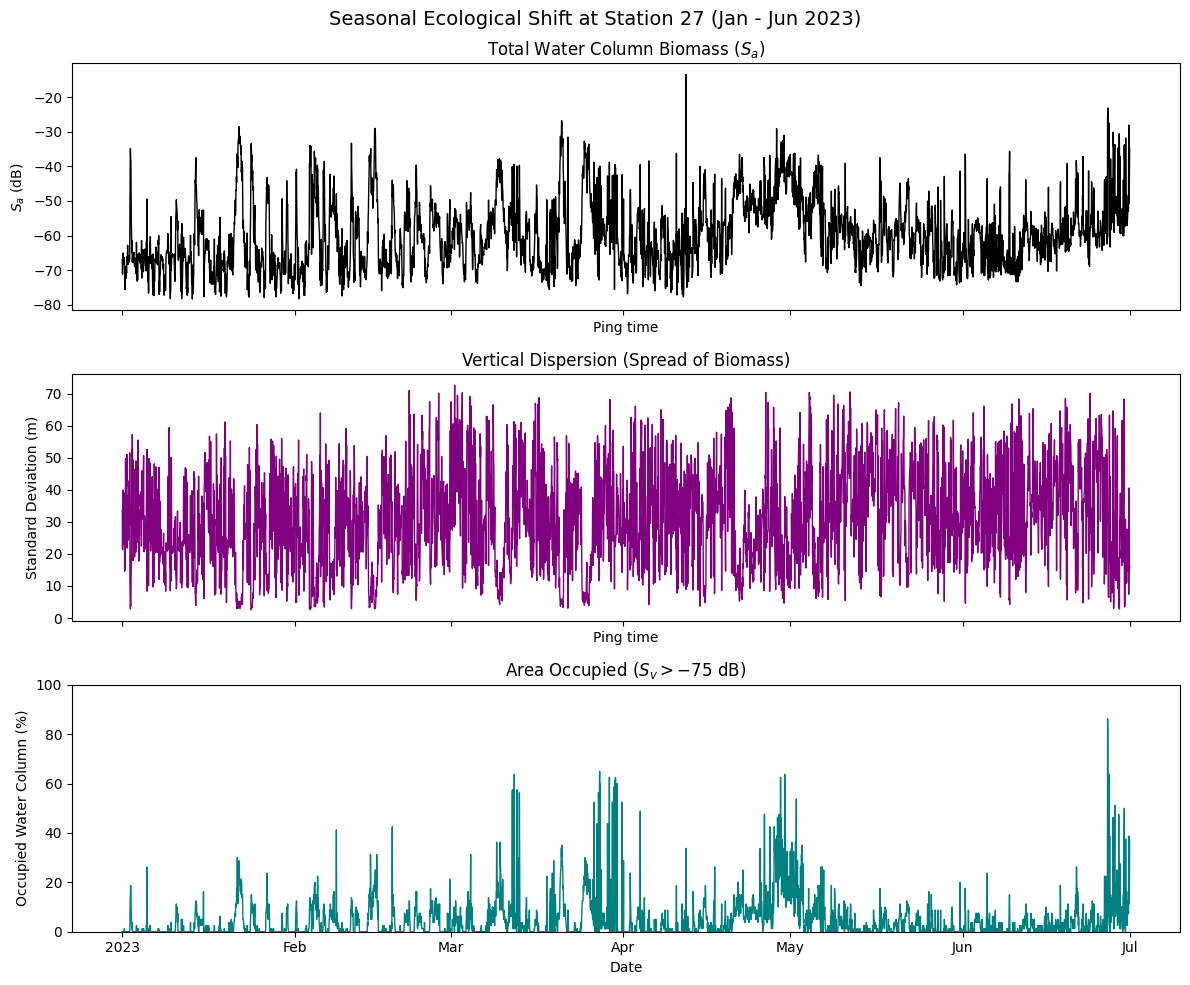

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CALCULATE THE NEW METRICS ---
print("Calculating advanced metrics...")

# A. Area Backscattering Coefficient (sa) - Total Biomass
# Sum the linear backscatter across the depth column and multiply by bin size (5m)
dz = 5 
ds_chan['sa'] = (ds_chan['sv_linear'] * dz).sum(dim='depth')
# Convert to logarithmic Sa (dB) for easier visualization
ds_chan['Sa_dB'] = 10 * np.log10(ds_chan['sa'])

# B. Dispersion (Standard Deviation of Depth around CM)
# Calculates how spread out the biomass is (in meters)
depth_diff_sq = (ds_chan.depth - ds_chan['center_of_mass'])**2
variance = (ds_chan['sv_linear'] * depth_diff_sq).sum(dim='depth') / ds_chan['sv_linear'].sum(dim='depth')
ds_chan['dispersion'] = np.sqrt(variance)

# C. Area Occupied (Meters of water column above a certain threshold)
# Let's say anything louder than -75 dB is "significant biomass"
threshold_dB = -75

# Create the boolean mask (True where Sv > threshold)
mask = ds_chan['Sv'] > threshold_dB

# Taking the mean of a boolean mask calculates the fraction of True values.
# Multiply by 100 to get the percentage.
ds_chan['area_occupied_pct'] = mask.mean(dim='depth') * 100


# --- 2. THE MACRO VIEW: 6-Month Ecological Trends ---
print("Generating 6-Month Macro Plot...")
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Total Biomass (Sa)
ds_chan['Sa_dB'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].set_title("Total Water Column Biomass ($S_a$)")
axes[0].set_ylabel("$S_a$ (dB)")

# Plot 2: Dispersion
ds_chan['dispersion'].plot(ax=axes[1], color='purple', linewidth=1)
axes[1].set_title("Vertical Dispersion (Spread of Biomass)")
axes[1].set_ylabel("Standard Deviation (m)")

# Plot 3: Area Occupied
# C. Area Occupied (Percentage of water column above threshold)


# --- UPDATED PLOT CODE FOR AREA OCCUPIED ---
# (Replace just the axes[2] section in your macro plot block)
ds_chan['area_occupied_pct'].plot(ax=axes[2], color='teal', linewidth=1)
axes[2].set_title("Area Occupied ($S_v > -75$ dB)")
axes[2].set_ylabel("Occupied Water Column (%)")
axes[2].set_xlabel("Date")
axes[2].set_ylim(0, 100) # 

plt.suptitle("Seasonal Ecological Shift at Station 27 (Jan - Jun 2023)", fontsize=14)
plt.tight_layout()
plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\s'
C:\Users\tofar\AppData\Local\Temp\ipykernel_13440\3242393158.py:55: SyntaxWarning: invalid escape sequence '\s'
  color='orange', alpha=0.4, label='Dispersion ($\sqrt{I}$)')


Calculating advanced metrics...
Generating 6-Month Macro Plot...


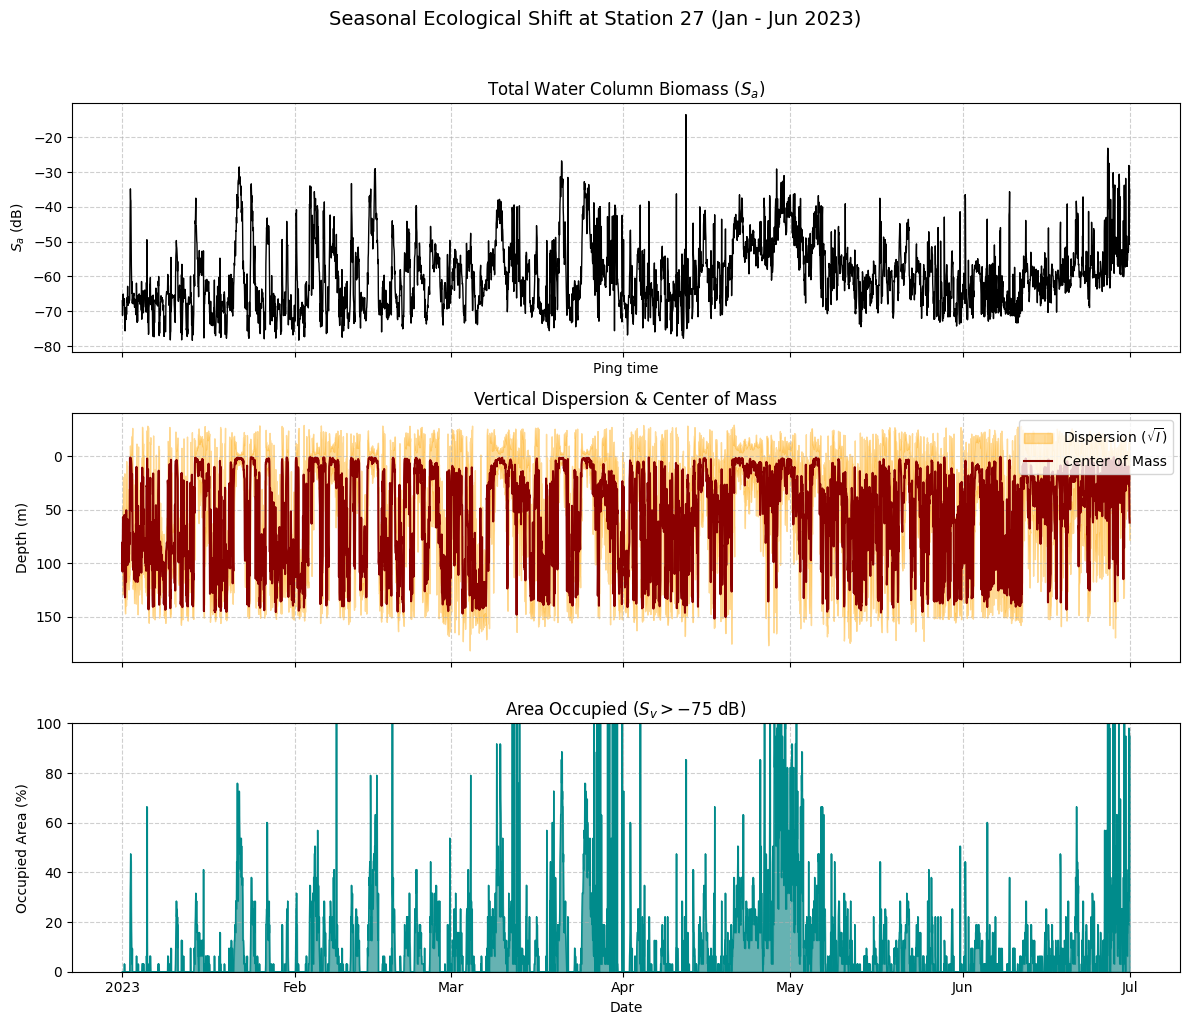

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CALCULATE METRICS (Using your robust logic) ---
print("Calculating advanced metrics...")

# A. Total Biomass (Sa)
dz = 5 
sv_sum = ds_chan['sv_linear'].sum(dim='depth', skipna=True)
ds_chan['Sa'] = sv_sum * dz
ds_chan['Sa_dB'] = 10 * np.log10(ds_chan['Sa'])

# B. Center of Mass & Dispersion (Inertia)
ds_chan['center_of_mass'] = (ds_chan['sv_linear'] * ds_chan.depth).sum(dim='depth', skipna=True) / sv_sum

# Calculate Inertia and Spread (Standard Deviation)
variance_z = ((ds_chan.depth - ds_chan['center_of_mass'])**2 * ds_chan['sv_linear']).sum(dim='depth', skipna=True)
ds_chan['inertia'] = variance_z / sv_sum
ds_chan['spread'] = np.sqrt(ds_chan['inertia']) 

# C. Area Occupied (Percentage based on H)
threshold_dB = -75
sv_thresh = 10 ** (threshold_dB / 10)

# Create boolean mask (1 if occupied, 0 if empty)
is_occupied = (ds_chan['sv_linear'] > sv_thresh).astype(int)

# Total observable depth range (H)
H = float(ds_chan.depth.max() - ds_chan.depth.min())

# Calculate percentage
ds_chan['area_occupied_pct'] = ((is_occupied.sum(dim='depth') * dz) / H) * 100


# --- 2. THE MACRO VIEW: 6-Month Ecological Trends ---
print("Generating 6-Month Macro Plot...")
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Extract numpy arrays for plotting
time_index = ds_chan['ping_time'].values
cm_values = ds_chan['center_of_mass'].values
spread_values = ds_chan['spread'].values
pocc_values = ds_chan['area_occupied_pct'].values

# Plot 1: Total Biomass (Sa)
ds_chan['Sa_dB'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].set_title("Total Water Column Biomass ($S_a$)")
axes[0].set_ylabel("$S_a$ (dB)")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Center of Mass & Dispersion (Using your Orange/DarkRed style)
axes[1].fill_between(time_index, 
                     cm_values - spread_values, 
                     cm_values + spread_values, 
                     color='orange', alpha=0.4, label='Dispersion ($\sqrt{I}$)')

axes[1].plot(time_index, cm_values, color='darkred', linewidth=1.5, label='Center of Mass')

axes[1].invert_yaxis() # Surface at the top
axes[1].set_title("Vertical Dispersion & Center of Mass")
axes[1].set_ylabel("Depth (m)")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')

# Plot 3: Area Occupied (Using your Teal/DarkCyan style)
axes[2].fill_between(time_index, 0, pocc_values, color='teal', alpha=0.6)
axes[2].plot(time_index, pocc_values, color='darkcyan', linewidth=1)

axes[2].set_title(f"Area Occupied ($S_v > {threshold_dB}$ dB)")
axes[2].set_ylabel("Occupied Area (%)")
axes[2].set_ylim(0, 100) # Locked 0 to 100%
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Date')
plt.suptitle("Seasonal Ecological Shift at Station 27 (Jan - Jun 2023)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# C. Area Occupied (Percentage of water column above threshold)
# Let's say anything louder than -75 dB is "significant biomass"
threshold_dB = -75

# Create the boolean mask (True where Sv > threshold)
mask = ds_chan['Sv'] > threshold_dB

# Taking the mean of a boolean mask calculates the fraction of True values.
# Multiply by 100 to get the percentage.
ds_chan['area_occupied_pct'] = mask.mean(dim='depth') * 100


# --- UPDATED PLOT CODE FOR AREA OCCUPIED ---
# (Replace just the axes[2] section in your macro plot block)
ds_chan['area_occupied_pct'].plot(ax=axes[2], color='teal', linewidth=1)
axes[2].set_title("Area Occupied ($S_v > -75$ dB)")
axes[2].set_ylabel("Occupied Water Column (%)")
axes[2].set_xlabel("Date")
axes[2].set_ylim(0, 100) # Locks the Y-axis to 0-100% for a true percentage view

(0.0, 100.0)

Generating Weekly Micro Plot (Echogram + CM)...


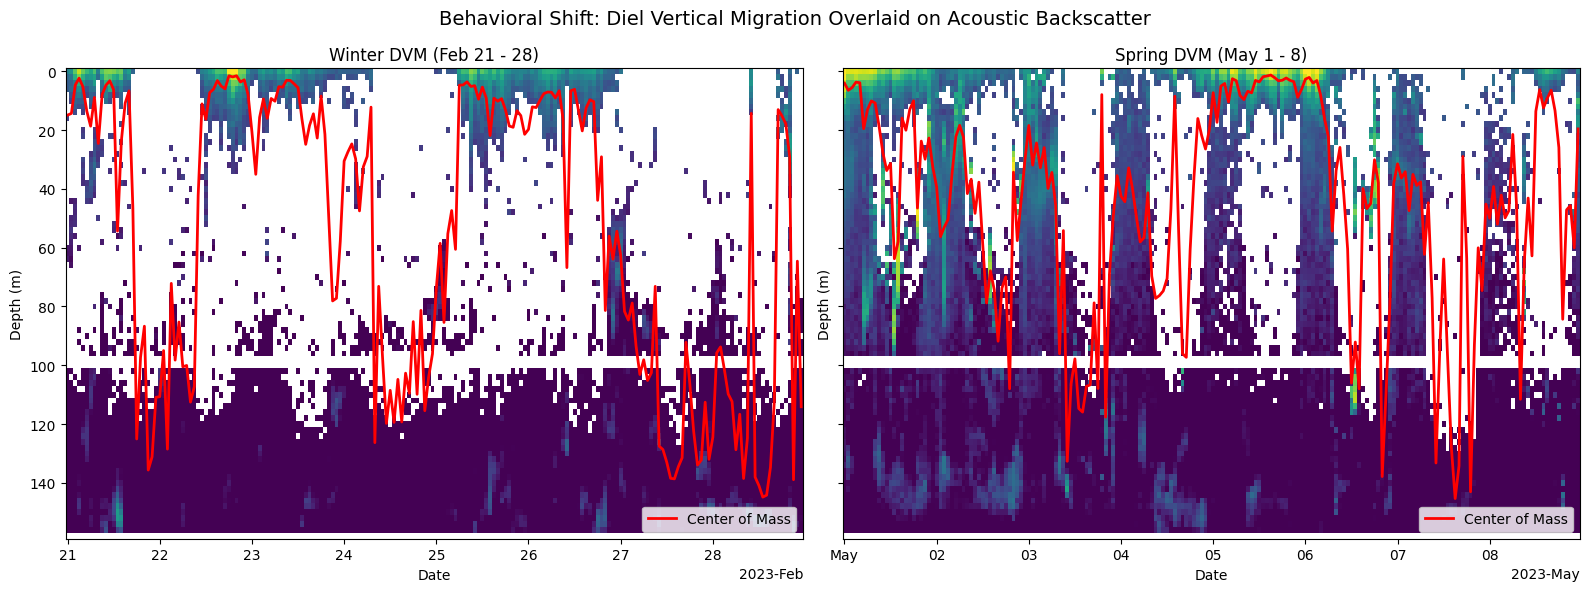

In [10]:
print("Generating Weekly Micro Plot (Echogram + CM)...")

# Define the specific weeks (You can adjust these dates later based on your scientific selection)
winter_slice = slice('2023-02-21', '2023-02-28')
spring_slice = slice('2023-05-1', '2023-05-8')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Function to plot echogram + CM overlay
def plot_weekly_dvm(ax, time_slice, title):
    data = ds_chan.sel(ping_time=time_slice)
    
    # 1. Plot the Echogram (Heatmap)
    mesh = data['Sv'].plot.pcolormesh(
        ax=ax, 
        x='ping_time', 
        y='depth', 
        yincrease=False, 
        cmap='viridis', 
        vmin=-85, vmax=-50,
        add_colorbar=False # We'll skip the colorbar here to keep it clean, or add one later
    )
    
    # 2. Overlay the Center of Mass (Red line)
    data['center_of_mass'].plot.line(ax=ax, x='ping_time', color='red', linewidth=2, label='Center of Mass')
    
    ax.set_title(title)
    ax.set_ylabel("Depth (m)")
    ax.set_xlabel("Date")
    ax.legend(loc='lower right')

# Generate the two panels
plot_weekly_dvm(axes[0], winter_slice, "Winter DVM (Feb 21 - 28)")
plot_weekly_dvm(axes[1], spring_slice, "Spring DVM (May 1 - 8)")

plt.suptitle("Behavioral Shift: Diel Vertical Migration Overlaid on Acoustic Backscatter", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# --- STATISTICAL COMPARISON ---
print("--- Statistical Summary of Center of Mass (CM) ---")

# Calculate Winter Stats
winter_mean = winter_dvm.mean().values
winter_std = winter_dvm.std().values
print(f"Winter (Feb 21-28): Mean Depth = {winter_mean:.1f}m, Standard Deviation = {winter_std:.1f}m")

# Calculate Spring Stats
spring_mean = spring_dvm.mean().values
spring_std = spring_dvm.std().values
print(f"Spring (May 1-8): Mean Depth = {spring_mean:.1f}m, Standard Deviation = {spring_std:.1f}m")


--- Statistical Summary of Center of Mass (CM) ---
Winter (Feb 21-28): Mean Depth = 55.0m, Standard Deviation = 46.8m
Spring (May 1-8): Mean Depth = 65.1m, Standard Deviation = 38.1m
